(glm_robust_pzy)=
# Heteroscedastic Bayesian Robust Regression

:::{post} 2026-04-30
:tags: regression, robust, linear model, heteroscedastic
:category: intermediate, explanation
:author: Pablo Vena
:::

In [1]:
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

In [2]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
# suppress pip-installed PyTensor BLAS warning (not actionable without conda)
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")

## Motivation

The PyMC gallery has two robust regression notebooks: one with a Student-t
likelihood ({ref}`pymc-examples:GLM-robust`) and one with the Hogg (2010)
signal-vs-noise mixture ({ref}`pymc-examples:GLM-robust-with-outlier-detection`).
Both protect against *vertical* outliers (points with unusual response values),
but neither defends against *leverage points*: observations far from the bulk
of the predictor space, which can drag the regression line even under a
heavy-tailed likelihood.

{cite:p}`pena2009bayesian` show that this is not specific to the Student-t:

- **Theorem 1.** No i.i.d. error model (Normal, Student-t, Laplace, or any
  scale mixture of normals) can achieve formal Kullback-Leibler robustness.
  A single observation moved far enough in the predictor space distorts the
  posterior of $\beta$ without bound.
- **Theorem 2.** A *heteroscedastic* model in which each observation receives
  a data-driven weight $w_i \in (0, 1]$ does achieve KL-robustness.

We implement that model here and compare it against the Normal and Student-t
baselines on three classic datasets.

## Model

Following the initials of the authors, we refer to the Peña-Zamar-Yan model
as **PZY** in the rest of the notebook. The PZY likelihood modifies Laplace
regression by scaling the noise parameter observation-by-observation:

$$
y_i \mid \beta, \sigma, w_i \;\sim\; \text{Laplace}\!\left(x_i^\top\beta,\;\frac{\sigma}{w_i}\right)
$$

Observations near the bulk of the data get $w_i = 1$ and are fit normally.
Observations far from the bulk get $w_i < 1$, which inflates their noise
scale and downweights their influence on the posterior of $\beta$. For
example, a point with $w_i = 0.1$ has its scale multiplied by 10; its
likelihood is therefore much wider and pulls the regression line much less
than a clean point would.

{cite:t}`pena2009bayesian` use the improper noninformative prior
$\pi(\beta, \sigma^2) \propto 1/\sigma^2$ in all their examples. We use the
closest PyMC equivalents: $\alpha, \beta_j \sim \text{Flat}$ and
$\sigma \sim \text{HalfFlat}$. The likelihood is informative enough that
the posterior is proper and NUTS samples it cleanly. For the Student-t
baseline we add $\nu \sim \text{Exponential}(1/30)$, the same prior used in
{ref}`pymc-examples:GLM-robust`.

### Computing the weights

Given the augmented matrix $Z = [y, X]$ (no intercept column):

1. **Robust location:** $m_j = \text{median}(z_{ij})$ for each coordinate $j$.
2. **Robust scale:** $s_j = \text{median}(|z_{ij} - m_j|)$, floored at $\varepsilon$.
3. **Quadrant correlation matrix $R$:** following {cite:t}`huber1981robust`,
   entry $(j,k)$ is the Pearson correlation between the sign vectors
   $\text{sign}(z_{j} - m_j)$ and $\text{sign}(z_{k} - m_k)$.
4. **Robust covariance proxy:** $C = D R D$ where $D = \text{diag}(s_1,\ldots,s_{p+1})$.
5. **Robust Mahalanobis distance:** $d_i = \sqrt{(z_i - m)^\top C^{-1}(z_i - m)}$.
6. **Cutoff:** $a = \text{median}(d) + k \cdot \text{MAD}(d)$, tuning parameter $k > 0$.
7. **Weights:**

$$
w_i = \begin{cases} 1 & d_i \leq a \\ (1 + d_i^2 - a^2)^{-1/2} & d_i > a \end{cases}
$$

The weights are computed once before MCMC. They are deterministic functions
of the data, not sampled random variables. The PyMC model wraps them in
{class}`~pymc.Data` so they appear in the graph alongside the design matrix.

In [3]:
def _quadrant_correlation(Z, medians):
    """Quadrant-correlation matrix as defined in {cite:p}`huber1981robust` and
    used by Peña-Zamar-Yan: the Pearson correlation between the sign vectors
    sign(z_j - m_j) and sign(z_k - m_k)."""
    signs = np.sign(Z - medians)
    centered = signs - signs.mean(axis=0)
    std = centered.std(axis=0, ddof=0)
    std[std == 0] = 1.0
    normed = centered / std
    R = (normed.T @ normed) / signs.shape[0]
    np.fill_diagonal(R, 1.0)
    return R


def pzy_weights(X, y, k=2.0, eps=1e-8):
    """Peña-Zamar-Yan (2009) heteroscedastic weights.

    Parameters
    ----------
    X : ndarray (n, p)  design matrix without intercept
    y : ndarray (n,)
    k : float           cutoff multiplier on MAD of distances
    eps : float         floor on coordinate MAD values

    Returns
    -------
    weights : ndarray (n,) in (0, 1]
    info    : dict with keys 'distances', 'cutoff', 'location'
    """
    Z = np.column_stack([y, X])
    location = np.median(Z, axis=0)
    scale = np.maximum(np.median(np.abs(Z - location), axis=0), eps)
    R = _quadrant_correlation(Z, location)
    C = np.diag(scale) @ R @ np.diag(scale)
    diff = Z - location
    d_sq = np.einsum("ij,jk,ik->i", diff, np.linalg.pinv(C), diff)
    distances = np.sqrt(np.maximum(d_sq, 0.0))
    med_d = np.median(distances)
    cutoff = med_d + k * np.median(np.abs(distances - med_d))
    above = distances > cutoff
    weights = np.ones(len(y))
    weights[above] = 1.0 / np.sqrt(1.0 + distances[above] ** 2 - cutoff**2)
    return weights, {"distances": distances, "cutoff": cutoff, "location": location}

In [4]:
def _fit(model, draws=2000, tune=2000, target_accept=0.9, max_treedepth=10):
    """Sample with NUTS, instantiating the step method explicitly so that
    target_accept and max_treedepth are reliably honored."""
    with model:
        step = pm.NUTS(target_accept=target_accept, max_treedepth=max_treedepth)
        return pm.sample(draws=draws, tune=tune, step=step, random_seed=RANDOM_SEED)


def fit_normal(X, y, predictor_names, **kw):
    n, _ = X.shape
    coords = {"predictor": predictor_names, "obs": np.arange(n)}
    with pm.Model(coords=coords) as model:
        intercept = pm.Flat("intercept")
        beta = pm.Flat("beta", dims="predictor")
        sigma = pm.HalfFlat("sigma")
        mu = intercept + pm.math.dot(pm.Data("X", X, dims=("obs", "predictor")), beta)
        pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y, dims="obs")
    return _fit(model, **kw), model


def fit_studentt(X, y, predictor_names, **kw):
    n, _ = X.shape
    coords = {"predictor": predictor_names, "obs": np.arange(n)}
    with pm.Model(coords=coords) as model:
        intercept = pm.Flat("intercept")
        beta = pm.Flat("beta", dims="predictor")
        sigma = pm.HalfFlat("sigma")
        nu = pm.Exponential("nu", lam=1.0 / 30.0)
        mu = intercept + pm.math.dot(pm.Data("X", X, dims=("obs", "predictor")), beta)
        pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")
    # The Exponential(1/30) prior on nu produces a heavy-tailed posterior with
    # difficult geometry; bump target_accept and max_treedepth to keep chains stable.
    kw.setdefault("target_accept", 0.95)
    kw.setdefault("max_treedepth", 15)
    return _fit(model, **kw), model


def fit_pzy(X, y, predictor_names, k=2.0, **kw):
    weights, info = pzy_weights(X, y, k=k)
    n, _ = X.shape
    coords = {"predictor": predictor_names, "obs": np.arange(n)}
    with pm.Model(coords=coords) as model:
        intercept = pm.Flat("intercept")
        beta = pm.Flat("beta", dims="predictor")
        sigma = pm.HalfFlat("sigma")
        w = pm.Data("weights", weights, dims="obs")
        mu = intercept + pm.math.dot(pm.Data("X", X, dims=("obs", "predictor")), beta)
        pm.Laplace("y_obs", mu=mu, b=sigma / w, observed=y, dims="obs")
    # Heavily downweighted points (small w) inflate b = sigma/w and create
    # funnel-like geometry; deeper trees help NUTS traverse it without warnings.
    kw.setdefault("target_accept", 0.95)
    kw.setdefault("max_treedepth", 15)
    return _fit(model, **kw), model, weights, info


def _slope_hdi(idata, pred, hdi_prob=0.95):
    """Posterior mean and HDI for a named coefficient. Flattens chains for the mean.
    The default 95% level matches the credible intervals reported in
    {cite:p}`pena2009bayesian`."""
    post = idata.posterior["beta"].sel(predictor=pred).values.ravel()
    hdi = az.hdi(idata, var_names=["beta"], prob=hdi_prob)["beta"].sel(predictor=pred)
    return post.mean(), float(hdi.isel(ci_bound=0)), float(hdi.isel(ci_bound=1))


def _plot_dataset(
    X_col,
    y,
    idata_dict,
    pred,
    weights,
    df_labels=None,
    xlabel="x",
    ylabel="response",
    title="",
    n_lines=200,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = {"Normal": "C0", "Student-t": "C1", "PZY": "C2"}

    # scatter + posterior regression lines
    ax = axes[0]
    x_line = np.linspace(X_col.min(), X_col.max(), 200).reshape(-1, 1)
    for name, idata in idata_dict.items():
        a_post = idata.posterior["intercept"].values.ravel()
        b_post = idata.posterior["beta"].sel(predictor=pred).values.ravel()
        n_draw = min(n_lines, len(a_post))
        idx = rng.choice(len(a_post), n_draw, replace=False)
        for i in idx:
            ax.plot(x_line, a_post[i] + b_post[i] * x_line, color=colors[name], alpha=0.03, lw=0.8)
        ax.plot(
            x_line, a_post.mean() + b_post.mean() * x_line, color=colors[name], lw=2, label=name
        )
    low_w = weights < 1.0
    ax.scatter(X_col, y, color="gray", s=25, zorder=3)
    ax.scatter(
        X_col[low_w], y[low_w], color="C1", s=55, zorder=4, marker="^", label="leverage (w < 1)"
    )
    if df_labels is not None:
        for i in np.where(low_w)[0]:
            ax.annotate(
                df_labels.iloc[i],
                (X_col[i], y[i]),
                fontsize=7,
                xytext=(4, 0),
                textcoords="offset points",
            )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

    # HDI comparison
    ax = axes[1]
    for i, (name, idata) in enumerate(idata_dict.items()):
        mean, lo, hi = _slope_hdi(idata, pred)
        ax.errorbar(
            mean, i, xerr=[[mean - lo], [hi - mean]], fmt="o", color=colors[name], capsize=5
        )
    ax.set_yticks(range(len(idata_dict)))
    ax.set_yticklabels(list(idata_dict.keys()))
    ax.set_xlabel("slope  (95 % CI)")
    ax.set_title(f"Slope posterior: {title}")
    ax.axvline(0, color="gray", ls="--", lw=0.8)

### Toy demonstration

We start with a synthetic example. Draw 30 clean points from the line
$y = 0.8\,x$ plus small noise, then add one bad leverage point: far from the
bulk in $x$-space, and far from the true line. Points within the cutoff
distance $a$ get weight 1; points beyond it get a smaller weight that
decreases as $d_i$ grows.

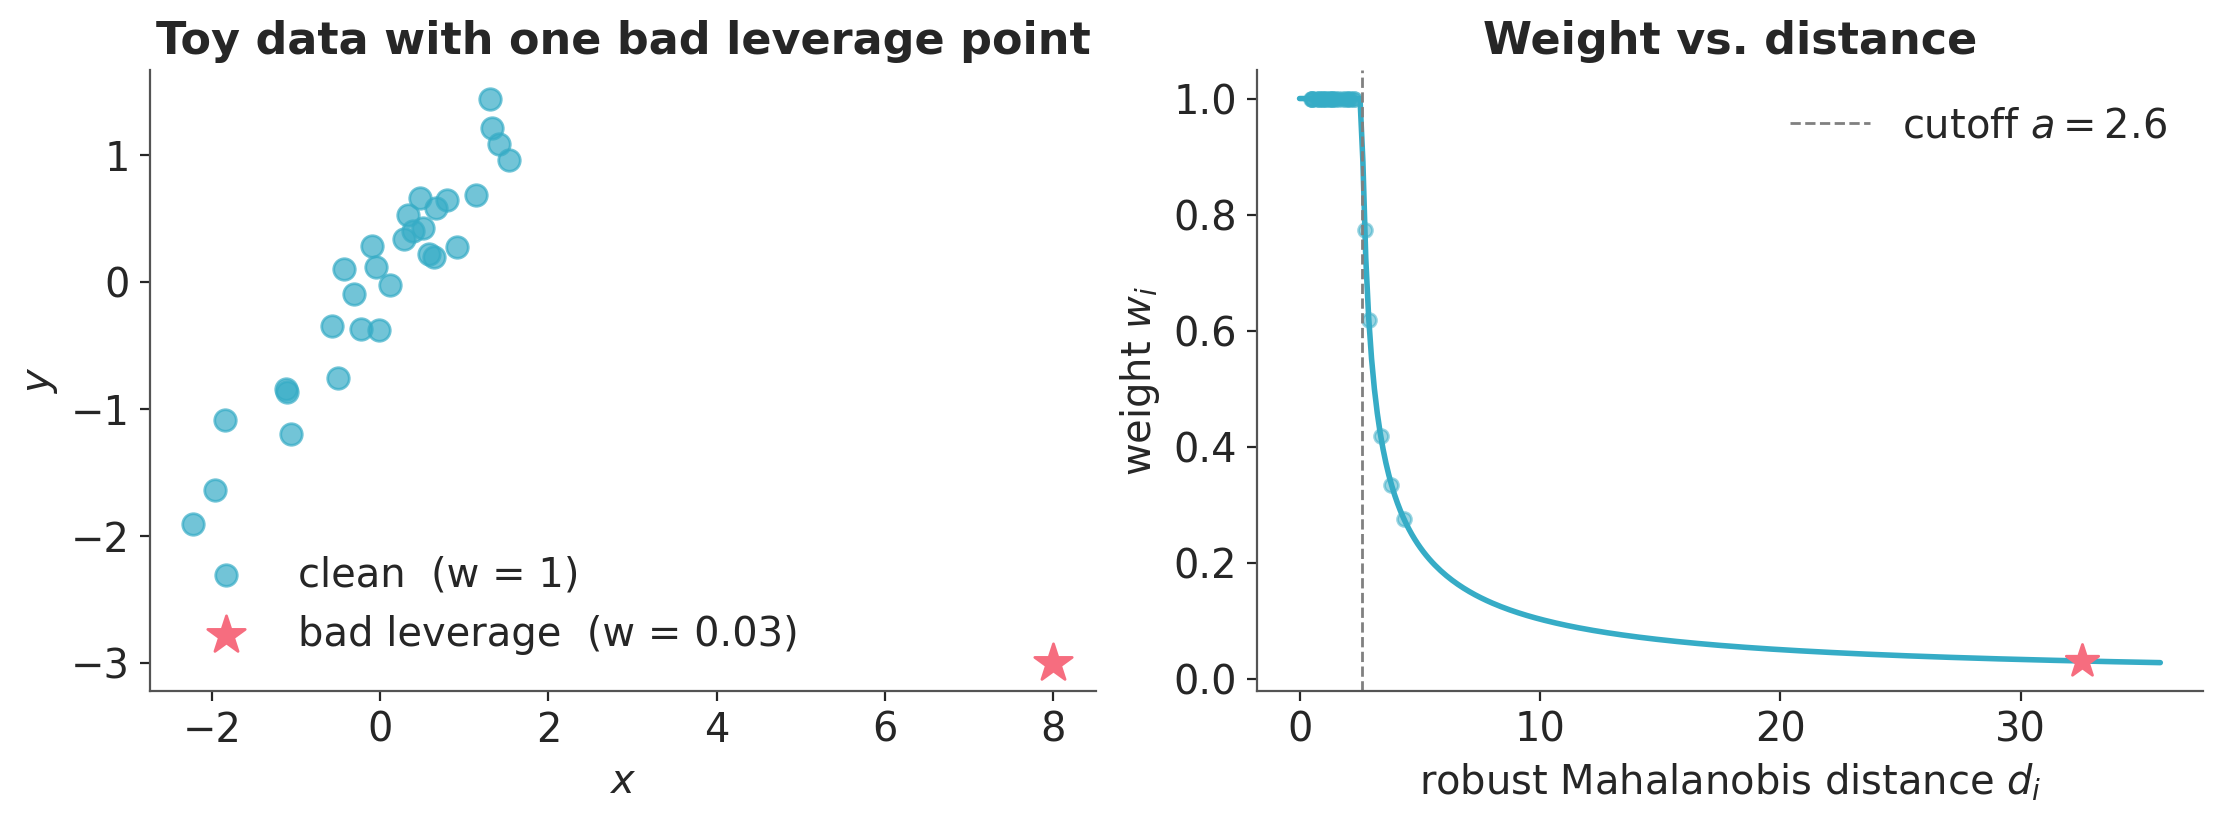

In [5]:
n_clean = 30
X_toy = rng.normal(0, 1, (n_clean, 1))
y_toy = 0.8 * X_toy[:, 0] + rng.normal(0, 0.3, n_clean)
# bad leverage point: large x, response inconsistent with the slope
X_demo = np.vstack([X_toy, [[8.0]]])
y_demo = np.append(y_toy, [-3.0])

weights_demo, info_demo = pzy_weights(X_demo, y_demo, k=2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.scatter(X_demo[:-1, 0], y_demo[:-1], s=60, alpha=0.7, color="C0", label="clean  (w = 1)")
ax.scatter(
    X_demo[-1, 0],
    y_demo[-1],
    s=200,
    color="C1",
    marker="*",
    zorder=5,
    label=f"bad leverage  (w = {weights_demo[-1]:.2f})",
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Toy data with one bad leverage point")
ax.legend()

ax = axes[1]
d_range = np.linspace(0, info_demo["distances"].max() * 1.1, 300)
a = info_demo["cutoff"]
w_curve = np.where(d_range <= a, 1.0, 1.0 / np.sqrt(np.maximum(1.0, 1 + d_range**2 - a**2)))
ax.plot(d_range, w_curve, color="C0", lw=2)
ax.axvline(a, color="gray", ls="--", lw=1, label=f"cutoff $a = {a:.1f}$")
ax.scatter(info_demo["distances"][:-1], weights_demo[:-1], color="C0", alpha=0.5, s=25)
ax.scatter(info_demo["distances"][-1], weights_demo[-1], color="C1", marker="*", s=150, zorder=5)
ax.set_xlabel("robust Mahalanobis distance $d_i$")
ax.set_ylabel("weight $w_i$")
ax.set_title("Weight vs. distance")
ax.legend()

## Dataset 1: brain and body weights

The `Animals` dataset from {cite:t}`venables2002mass` has body weight (kg) and
brain weight (g) for 28 species. On a log-log scale the relationship is
roughly linear, except for a handful of species at the extremes: dinosaurs at
the top end (very large body, small brain relative to body) and the smallest
rodents at the bottom end. The Normal and Student-t fits are pulled toward
those points. PZY downweights them and recovers a steeper slope, close to
the slope you would estimate from the bulk alone.

In [6]:
try:
    animals_df = pd.read_csv(os.path.join("..", "data", "animals.csv"))
except FileNotFoundError:
    animals_df = pd.read_csv("data/animals.csv")

animals_X = np.log(animals_df["body_kg"].values).reshape(-1, 1)
animals_y = np.log(animals_df["brain_g"].values)

animals_normal_idata, animals_normal_model = fit_normal(
    animals_X, animals_y, predictor_names=["log_body"]
)
animals_studentt_idata, animals_studentt_model = fit_studentt(
    animals_X, animals_y, predictor_names=["log_body"]
)
animals_pzy_idata, animals_pzy_model, animals_weights, animals_info = fit_pzy(
    animals_X, animals_y, predictor_names=["log_body"], k=2.0
)

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


Multiprocess sampling (4 chains in 4 jobs)


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


Animals: slope 95 % CI (this notebook vs paper Table 1)
  Normal        mean=0.496  ours=(0.326, 0.652)  paper=(0.33, 0.66)
  Student-t     mean=0.710  ours=(0.483, 0.828)
  PZY           mean=0.705  ours=(0.586, 0.817)  paper=(0.67, 0.83)


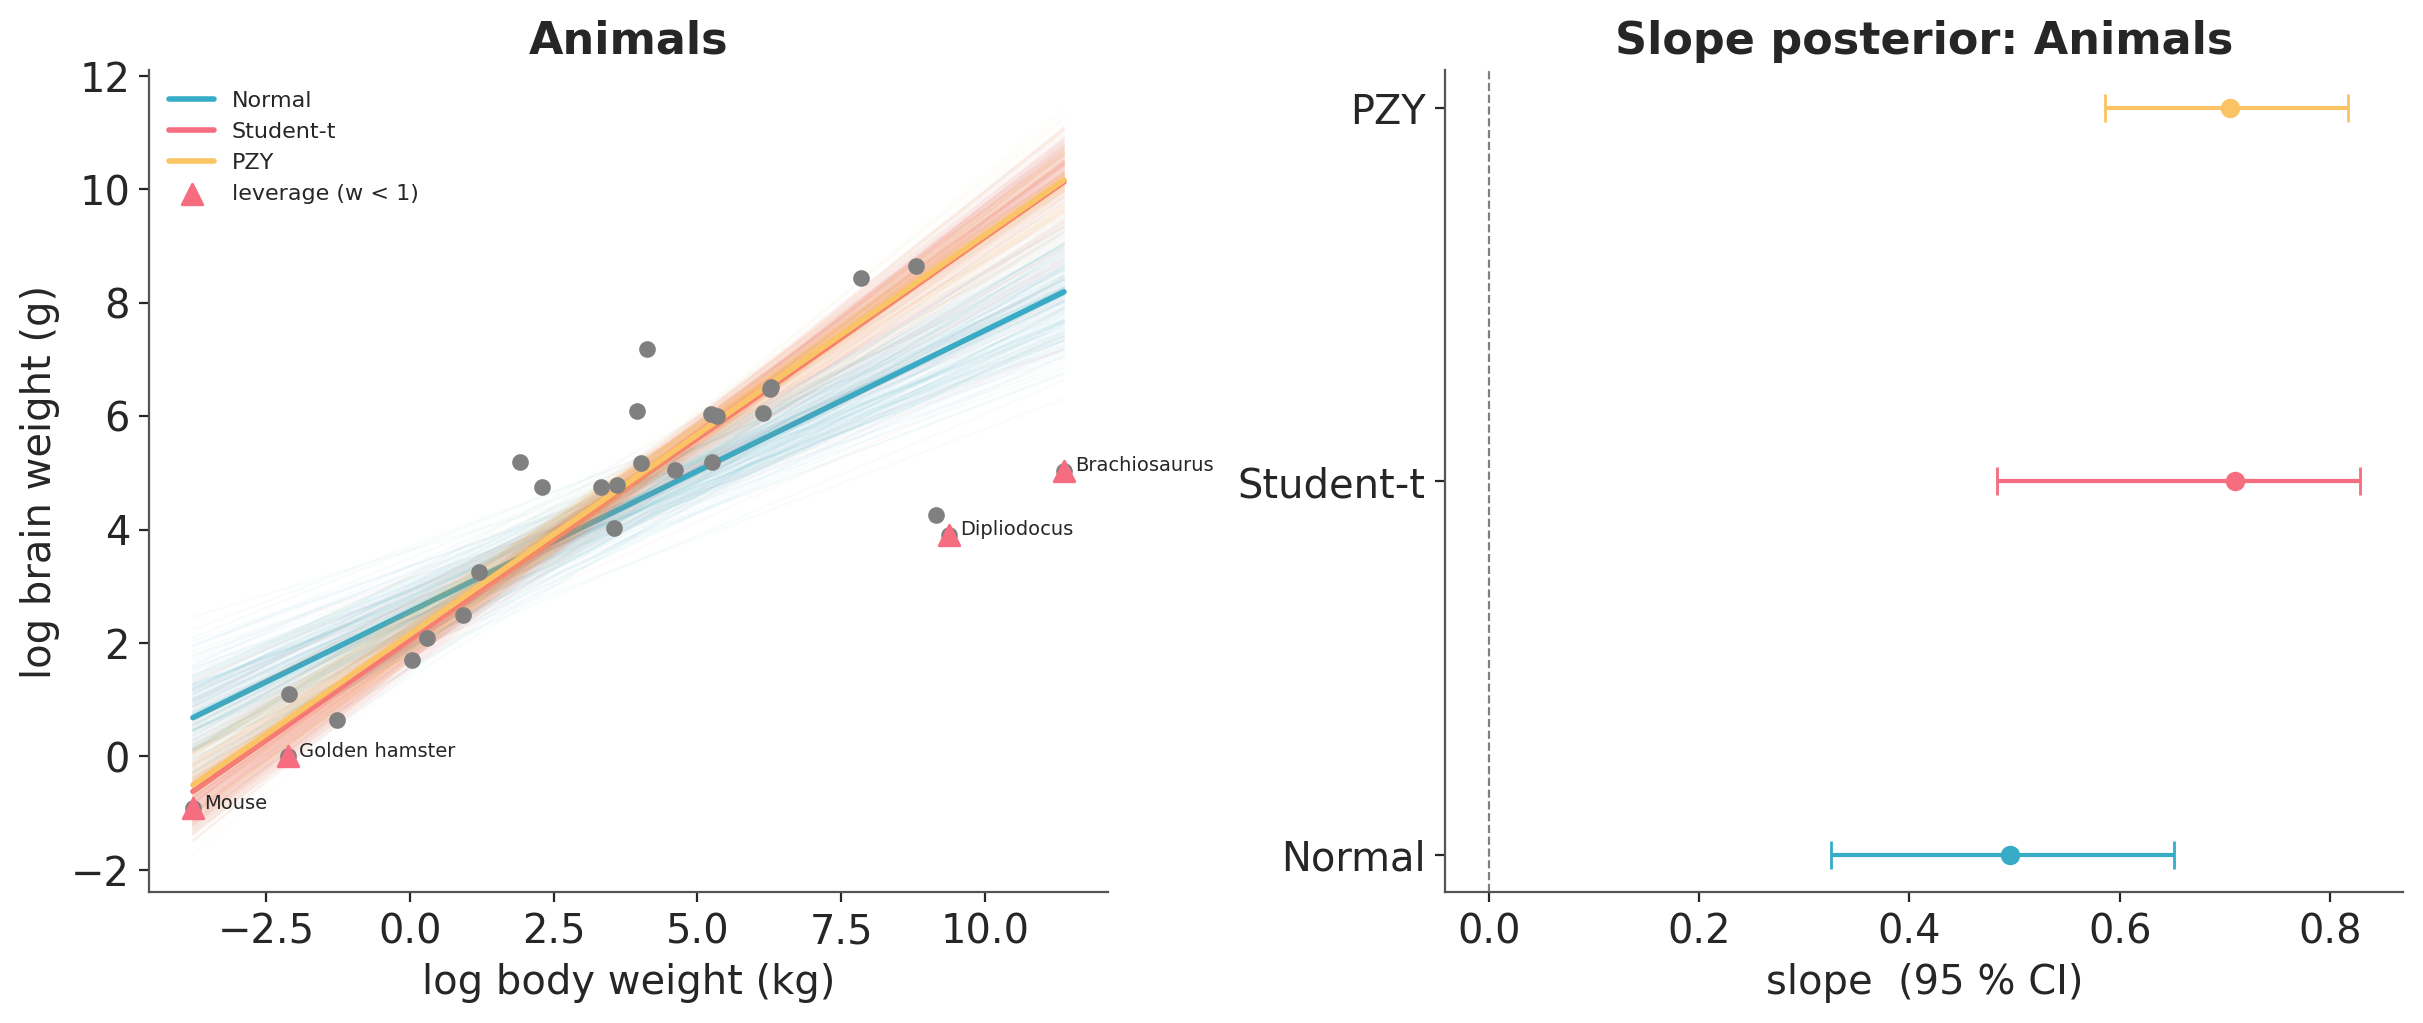

In [7]:
_plot_dataset(
    animals_X[:, 0],
    animals_y,
    {"Normal": animals_normal_idata, "Student-t": animals_studentt_idata, "PZY": animals_pzy_idata},
    pred="log_body",
    weights=animals_weights,
    df_labels=animals_df["species"],
    xlabel="log body weight (kg)",
    ylabel="log brain weight (g)",
    title="Animals",
)

print("Animals: slope 95 % CI (this notebook vs paper Table 1)")
paper_animals = {"Normal": (0.33, 0.66), "PZY": (0.67, 0.83)}
for name, idata in [
    ("Normal", animals_normal_idata),
    ("Student-t", animals_studentt_idata),
    ("PZY", animals_pzy_idata),
]:
    mean, lo, hi = _slope_hdi(idata, "log_body")
    paper = paper_animals.get(name)
    paper_str = f"  paper=({paper[0]:.2f}, {paper[1]:.2f})" if paper else ""
    print(f"  {name:12s}  mean={mean:.3f}  ours=({lo:.3f}, {hi:.3f}){paper_str}")

### Convergence and posterior predictive checks

We first check the PZY chains for convergence (see the [ArviZ MCMC
diagnostics chapter](https://arviz-devs.github.io/EABM/Chapters/MCMC_diagnostics.html)
for guidance on $\hat{R}$ and ESS). Then for each model we draw replicated
datasets and a posterior predictive PIT plot. The Normal predictive
distribution is too narrow to cover the extreme species. The Student-t
covers them by giving every observation heavy tails. PZY covers them by
inflating the noise scale only at the downweighted points. A
well-calibrated model produces PPC-PIT values close to uniform.

                 mean     sd  ess_bulk  ess_tail r_hat
intercept        2.15  0.292      2378      3602  1.00
beta[log_body]  0.705   0.06      2314      3218  1.00
sigma           0.855  0.175      3660      3652  1.00


Sampling: [y_obs]


Sampling: [y_obs]


Sampling: [y_obs]


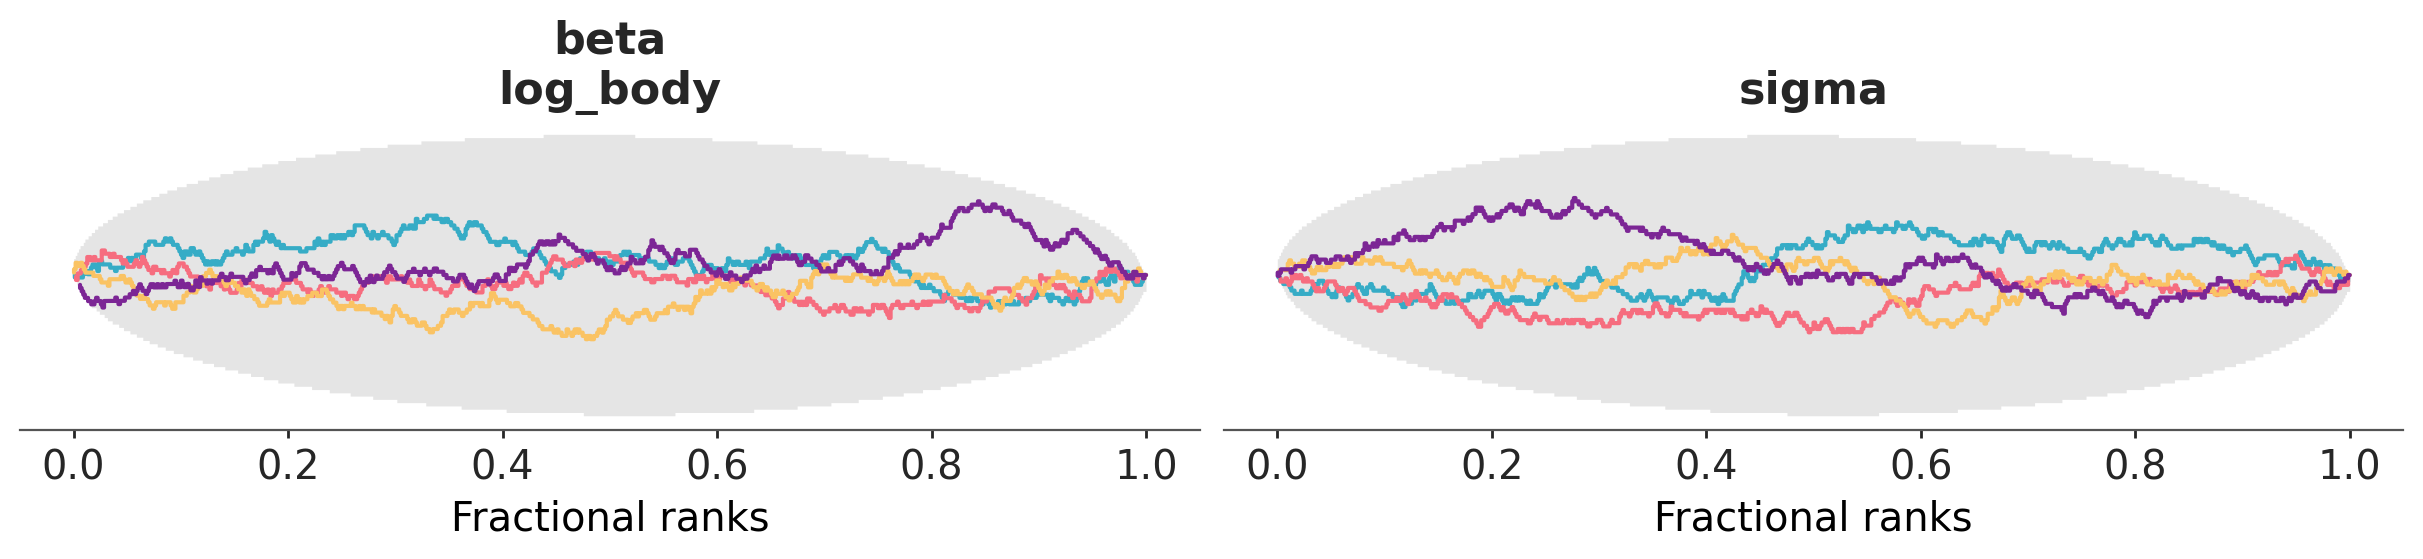

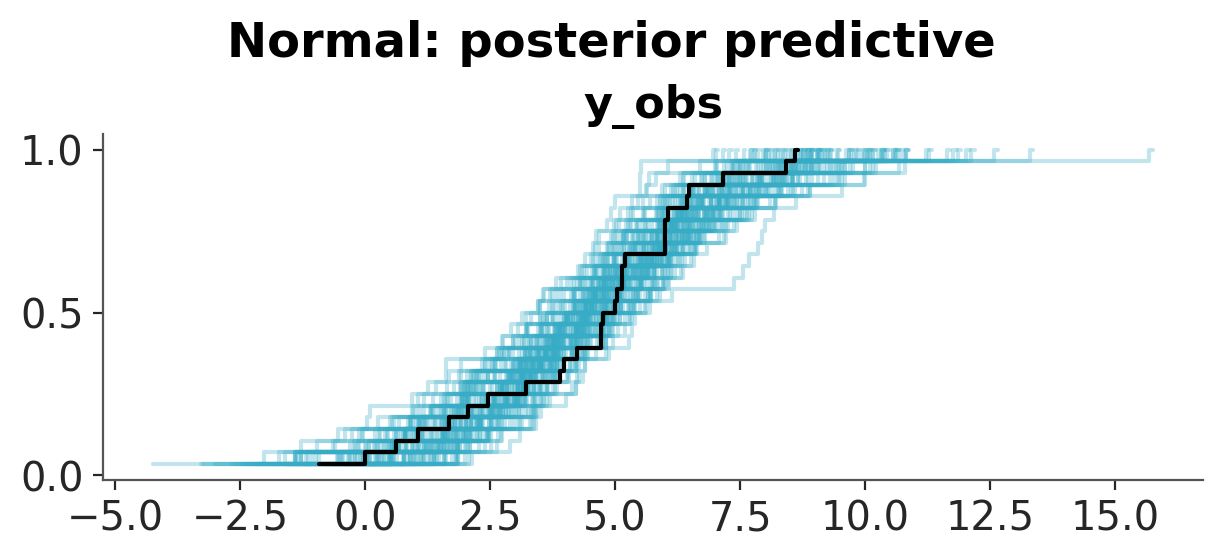

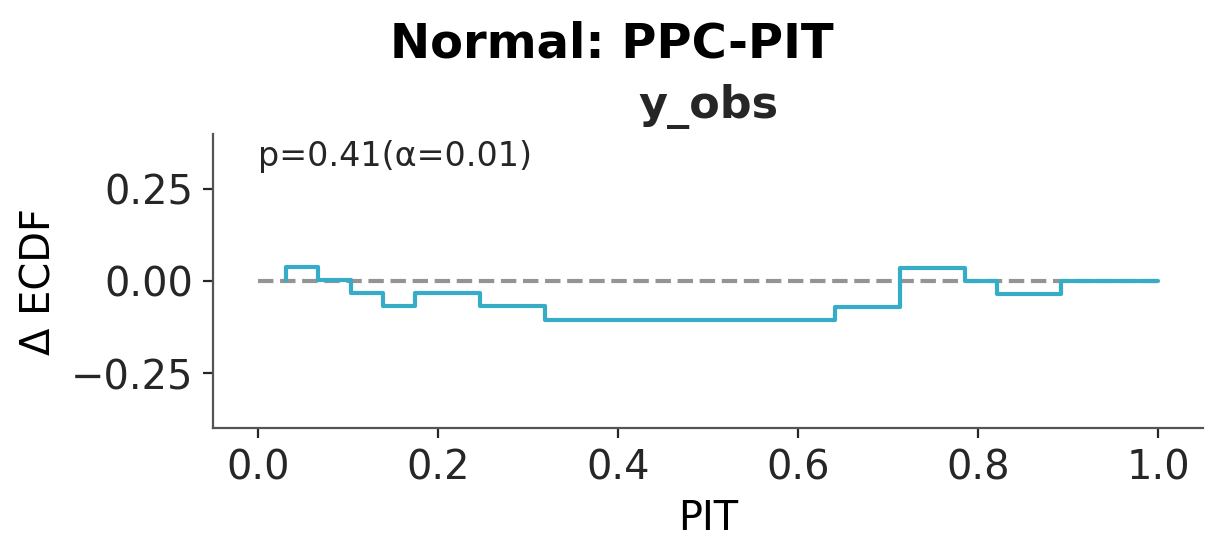

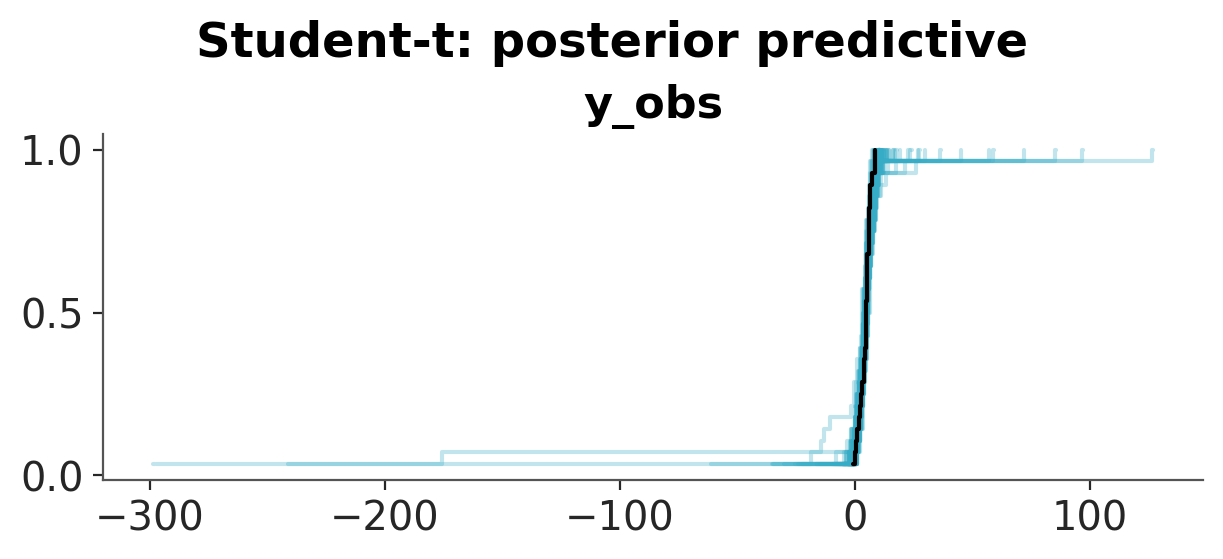

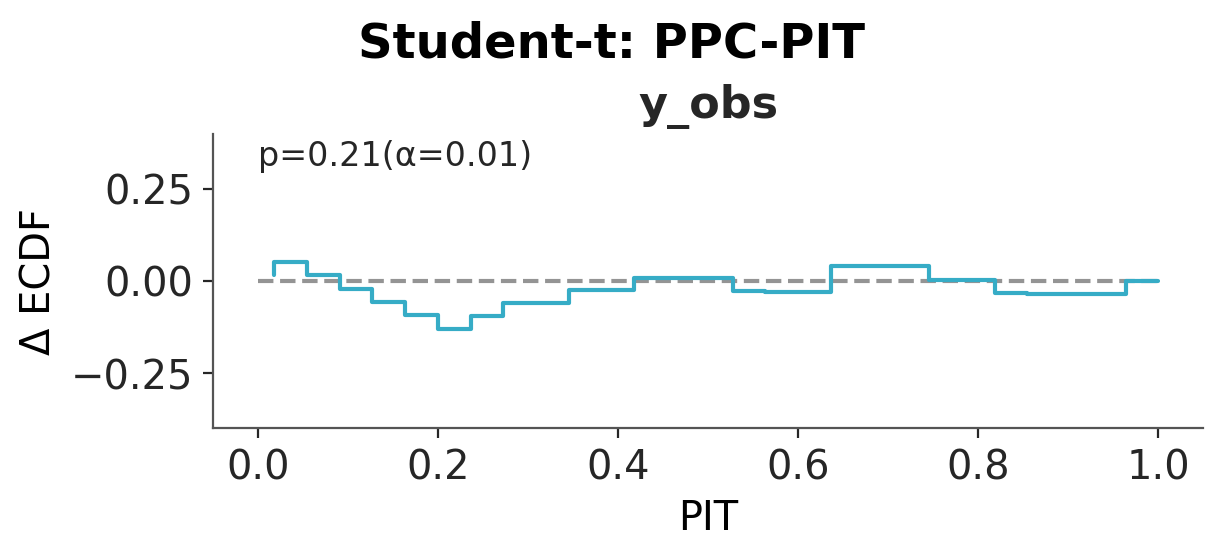

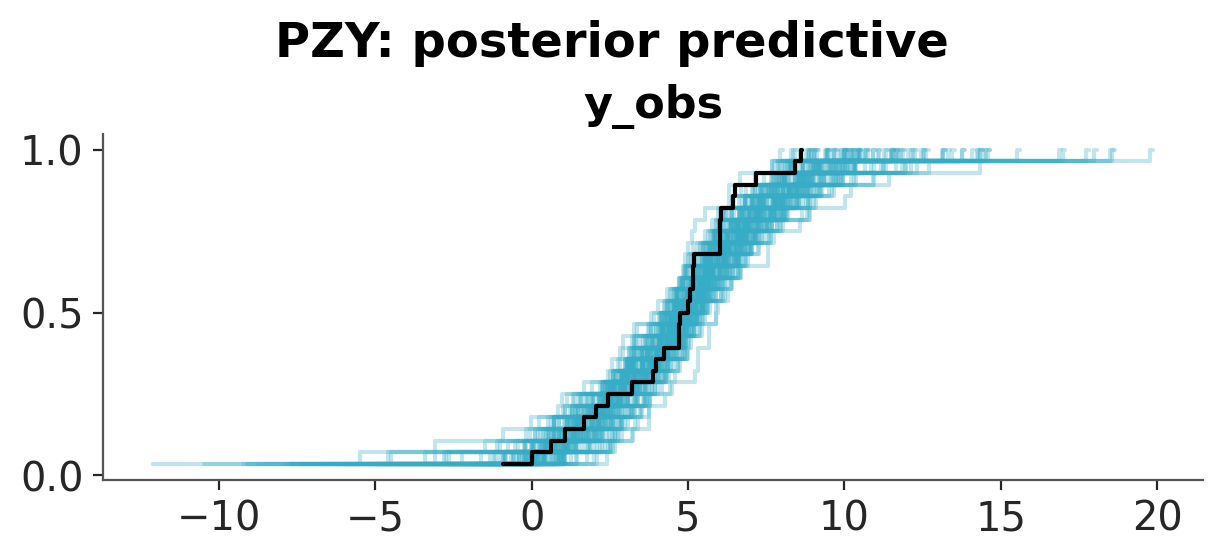

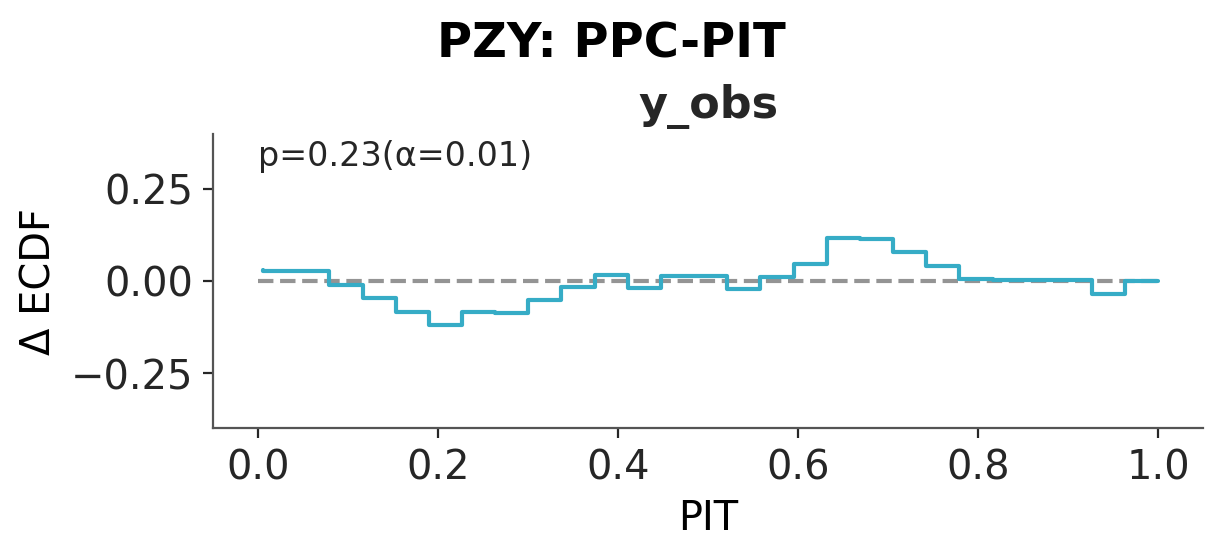

In [8]:
print(
    az.summary(animals_pzy_idata, var_names=["intercept", "beta", "sigma"])[
        ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]
    ]
)
az.plot_rank(animals_pzy_idata, var_names=["beta", "sigma"])

animals_models = {
    "Normal": animals_normal_model,
    "Student-t": animals_studentt_model,
    "PZY": animals_pzy_model,
}
animals_idatas = {
    "Normal": animals_normal_idata,
    "Student-t": animals_studentt_idata,
    "PZY": animals_pzy_idata,
}
animals_ppcs = {}
for name, model in animals_models.items():
    with model:
        animals_ppcs[name] = pm.sample_posterior_predictive(
            animals_idatas[name], random_seed=RANDOM_SEED, progressbar=False
        )
        # merge posterior_predictive into the inference data tree
        animals_idatas[name]["posterior_predictive"] = animals_ppcs[name]["posterior_predictive"]

for name, idata in animals_idatas.items():
    pc = az.plot_ppc_dist(idata, num_samples=100)
    pc.add_title(f"{name}: posterior predictive")
    pc = az.plot_ppc_pit(idata)
    pc.add_title(f"{name}: PPC-PIT")

## Dataset 2: CYG OB1 star cluster

{cite:t}`rousseeuw2005robust` use the Hertzsprung-Russell diagram for 47 stars
in the CYG OB1 cluster {cite:p}`humphreys1978studies`. The predictor is
$\log_{10}$ effective temperature, and the response is $\log_{10}$ light
intensity. Four giant stars sit apart from the rest: they are cool (low
$\log_{10} T_e$) but very bright (high $\log_{10} L$). These four points pull
ordinary regression to a negative slope, the opposite of the expected
main-sequence pattern (hotter stars are brighter). PZY downweights the
giants and recovers a positive slope.

In [9]:
try:
    cyg_df = pd.read_csv(os.path.join("..", "data", "stars_cyg.csv"))
except FileNotFoundError:
    cyg_df = pd.read_csv("data/stars_cyg.csv")

cyg_X = cyg_df["log.Te"].values.reshape(-1, 1)
cyg_y = cyg_df["log.light"].values

cyg_normal_idata, _ = fit_normal(cyg_X, cyg_y, predictor_names=["log_Te"])
cyg_studentt_idata, _ = fit_studentt(cyg_X, cyg_y, predictor_names=["log_Te"])
cyg_pzy_idata, _, cyg_weights, cyg_info = fit_pzy(cyg_X, cyg_y, predictor_names=["log_Te"], k=2.0)

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.


Multiprocess sampling (4 chains in 4 jobs)


...

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 13 seconds.


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 82 seconds.


CYG OB1: slope 95 % CI (this notebook vs paper Table 2)
  Normal        mean=-0.418  ours=(-0.988, 0.182)  paper=(-1.00, 0.15)
  Student-t     mean=-0.395  ours=(-0.991, 0.225)
  PZY           mean=2.783  ours=(1.777, 3.861)  paper=(1.96, 3.98)


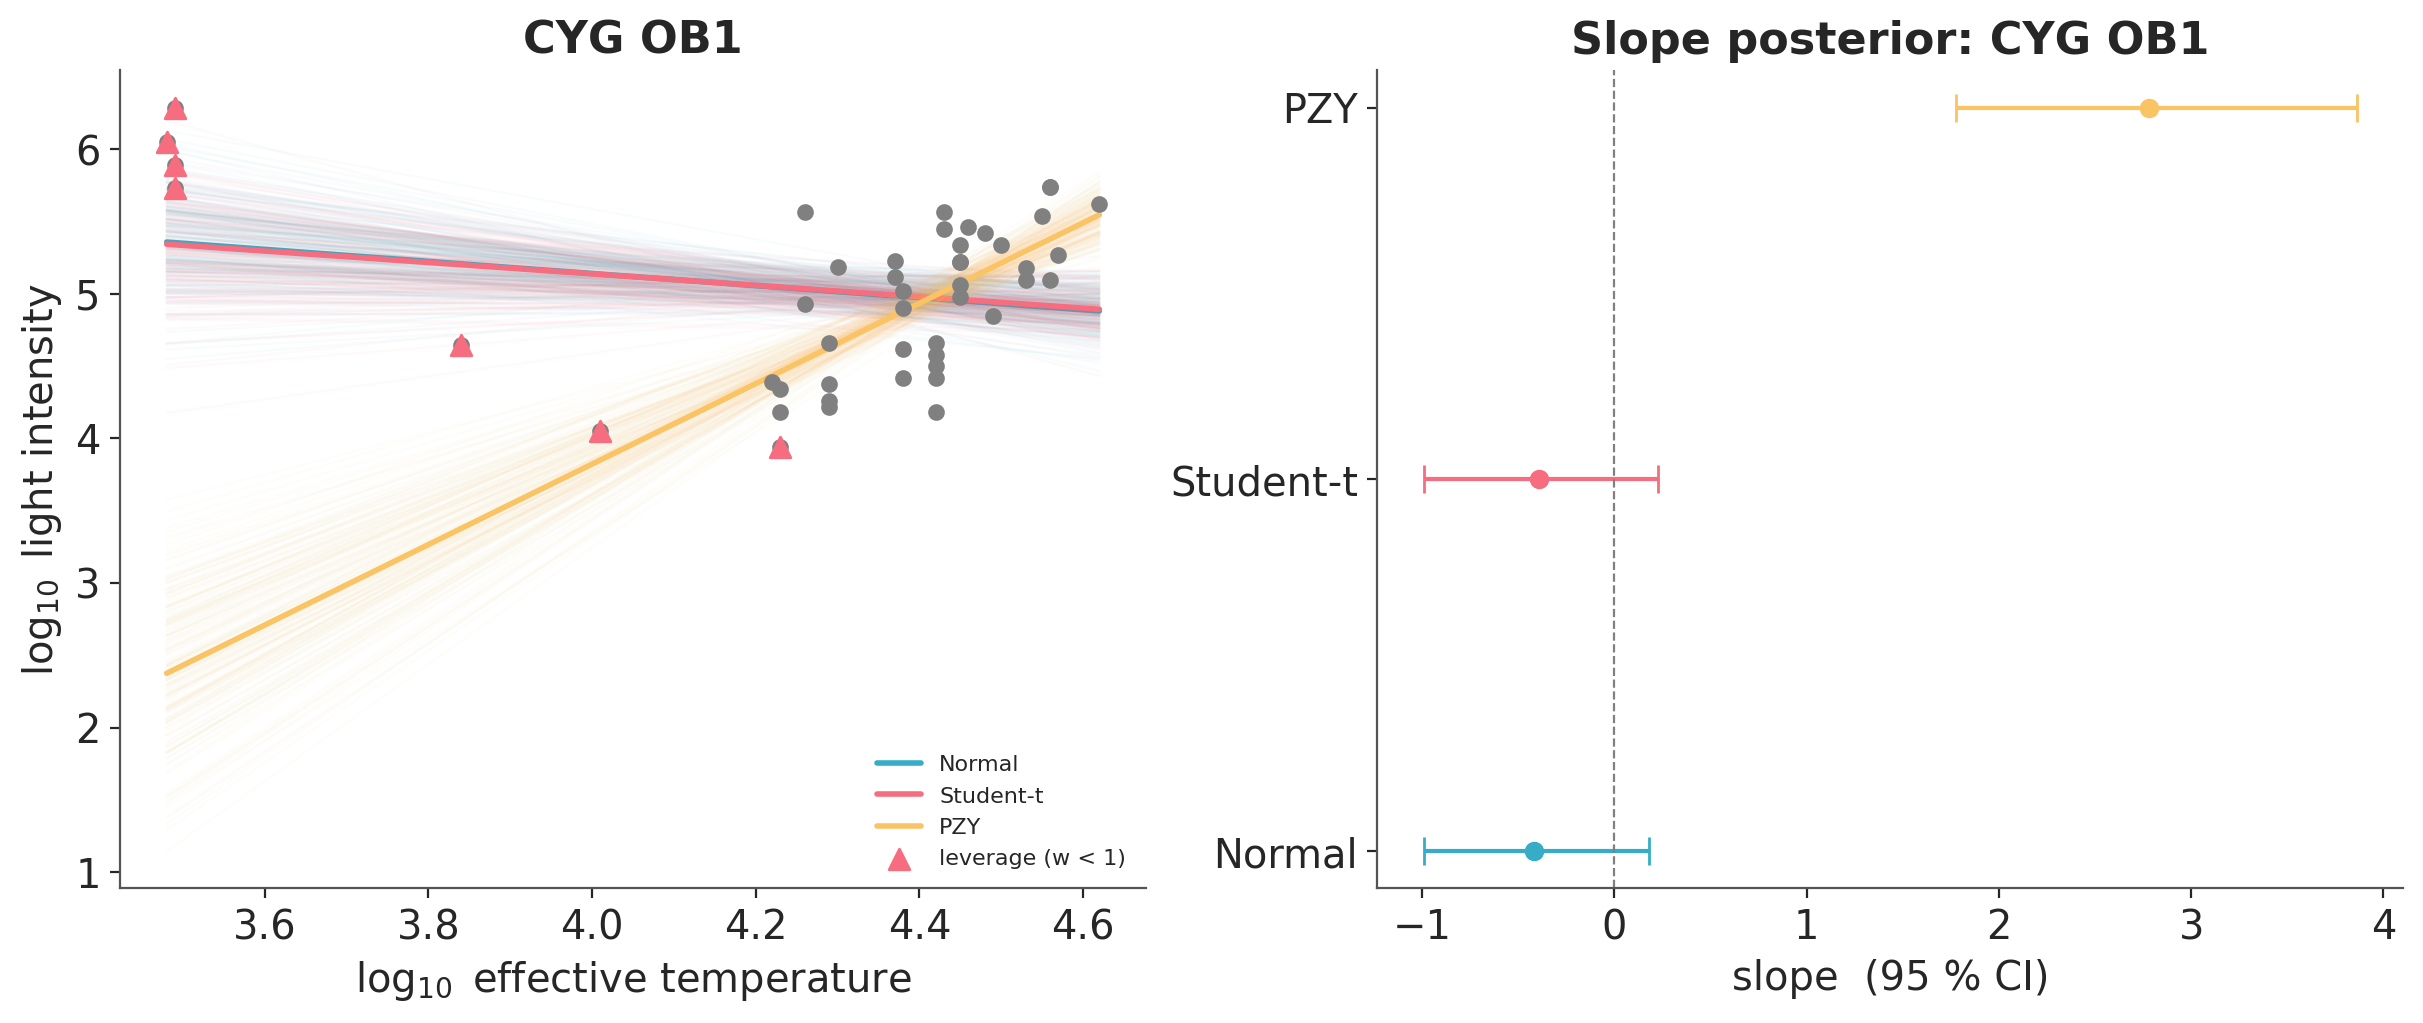

In [10]:
_plot_dataset(
    cyg_X[:, 0],
    cyg_y,
    {"Normal": cyg_normal_idata, "Student-t": cyg_studentt_idata, "PZY": cyg_pzy_idata},
    pred="log_Te",
    weights=cyg_weights,
    xlabel="$\\log_{10}$ effective temperature",
    ylabel="$\\log_{10}$ light intensity",
    title="CYG OB1",
)

print("CYG OB1: slope 95 % CI (this notebook vs paper Table 2)")
paper_cyg = {"Normal": (-1.00, 0.15), "PZY": (1.96, 3.98)}
for name, idata in [
    ("Normal", cyg_normal_idata),
    ("Student-t", cyg_studentt_idata),
    ("PZY", cyg_pzy_idata),
]:
    mean, lo, hi = _slope_hdi(idata, "log_Te")
    paper = paper_cyg.get(name)
    paper_str = f"  paper=({paper[0]:.2f}, {paper[1]:.2f})" if paper else ""
    print(f"  {name:12s}  mean={mean:.3f}  ours=({lo:.3f}, {hi:.3f}){paper_str}")

## Dataset 3: Hawkins-Bradu-Kass

The {cite:t}`hawkins1984location` dataset has 75 observations on three
predictors, designed so that the first 14 rows are leverage points: the first
10 have large predictor values *and* large response values (bad leverage),
and rows 11-14 have large predictor values but response near zero (good
leverage, consistent with the bulk pattern). The remaining 61 observations
cluster near the origin. The true regression coefficients for the bulk are
all zero. The Normal and Student-t likelihoods are pulled by the 10 bad
leverage points. PZY downweights all 14 leverage points and recovers slopes
whose 95 % CIs include zero.

In [11]:
try:
    hbk_df = pd.read_csv(os.path.join("..", "data", "hbk.csv"))
except FileNotFoundError:
    hbk_df = pd.read_csv("data/hbk.csv")

hbk_X = hbk_df[["X1", "X2", "X3"]].values
hbk_y = hbk_df["Y"].values

hbk_normal_idata, _ = fit_normal(hbk_X, hbk_y, predictor_names=["X1", "X2", "X3"])
hbk_studentt_idata, _ = fit_studentt(hbk_X, hbk_y, predictor_names=["X1", "X2", "X3"])
hbk_pzy_idata, _, hbk_weights, hbk_info = fit_pzy(
    hbk_X, hbk_y, predictor_names=["X1", "X2", "X3"], k=2.0
)

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5 seconds.


Multiprocess sampling (4 chains in 4 jobs)


...

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 9 seconds.


HBK: coefficient 95 % CIs (true values: all zero)
Model                         X1                  X2                  X3
  Normal        +0.23 (-0.29, +0.79)  -0.34 (-0.65, -0.03)  +0.39 (+0.13, +0.64)
  Student-t     +0.14 (-0.04, +0.34)  +0.21 (+0.05, +0.38)  +0.17 (+0.05, +0.30)
  PZY           +0.13 (-0.02, +0.29)  +0.10 (-0.05, +0.25)  -0.06 (-0.20, +0.08)
Paper Table 3 PZY:    +0.06 (-0.06, +0.19)  +0.02 (-0.11, +0.14)  -0.12 (-0.24, +0.01)


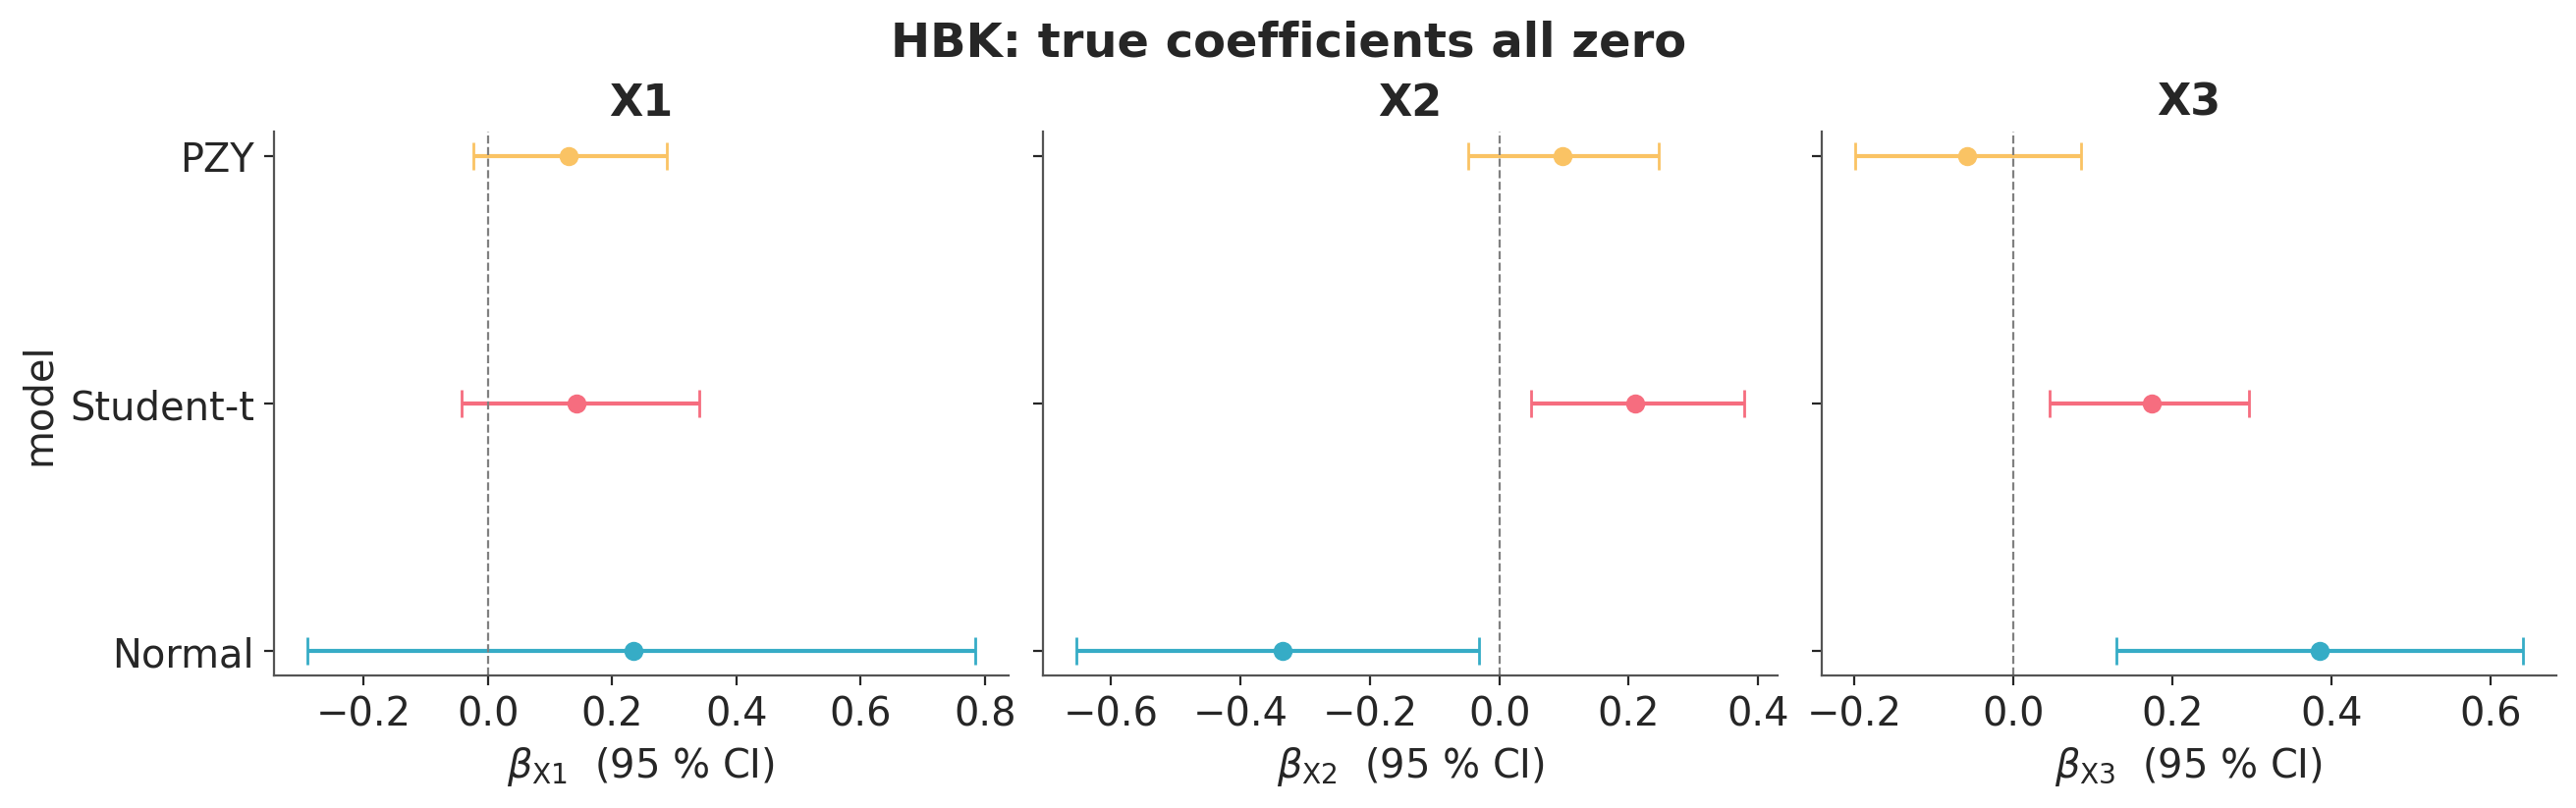

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
colors = {"Normal": "C0", "Student-t": "C1", "PZY": "C2"}

for ax, pred in zip(axes, ["X1", "X2", "X3"]):
    for i, (name, idata) in enumerate(
        [("Normal", hbk_normal_idata), ("Student-t", hbk_studentt_idata), ("PZY", hbk_pzy_idata)]
    ):
        mean, lo, hi = _slope_hdi(idata, pred)
        ax.errorbar(
            mean, i, xerr=[[mean - lo], [hi - mean]], fmt="o", color=colors[name], capsize=5
        )
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Normal", "Student-t", "PZY"])
    ax.axvline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel(f"$\\beta_{{\\text{{{pred}}}}}$  (95 % CI)")
    ax.set_title(pred)

axes[0].set_ylabel("model")
fig.suptitle("HBK: true coefficients all zero")

print("HBK: coefficient 95 % CIs (true values: all zero)")
print(f"{'Model':12s}  {'X1':>18s}  {'X2':>18s}  {'X3':>18s}")
for name, idata in [
    ("Normal", hbk_normal_idata),
    ("Student-t", hbk_studentt_idata),
    ("PZY", hbk_pzy_idata),
]:
    row = []
    for pred in ["X1", "X2", "X3"]:
        mean, lo, hi = _slope_hdi(idata, pred)
        row.append(f"{mean:+.2f} ({lo:+.2f}, {hi:+.2f})")
    print(f"  {name:12s}  {'  '.join(row)}")
print("Paper Table 3 PZY:    " "+0.06 (-0.06, +0.19)  +0.02 (-0.11, +0.14)  -0.12 (-0.24, +0.01)")

## Weights across datasets

The plot below shows each observation's PZY weight against its robust
Mahalanobis distance, for all three datasets. Points left of the dashed
cutoff line have weight 1. Points to the right are downweighted smoothly,
with weight decreasing as the distance grows.

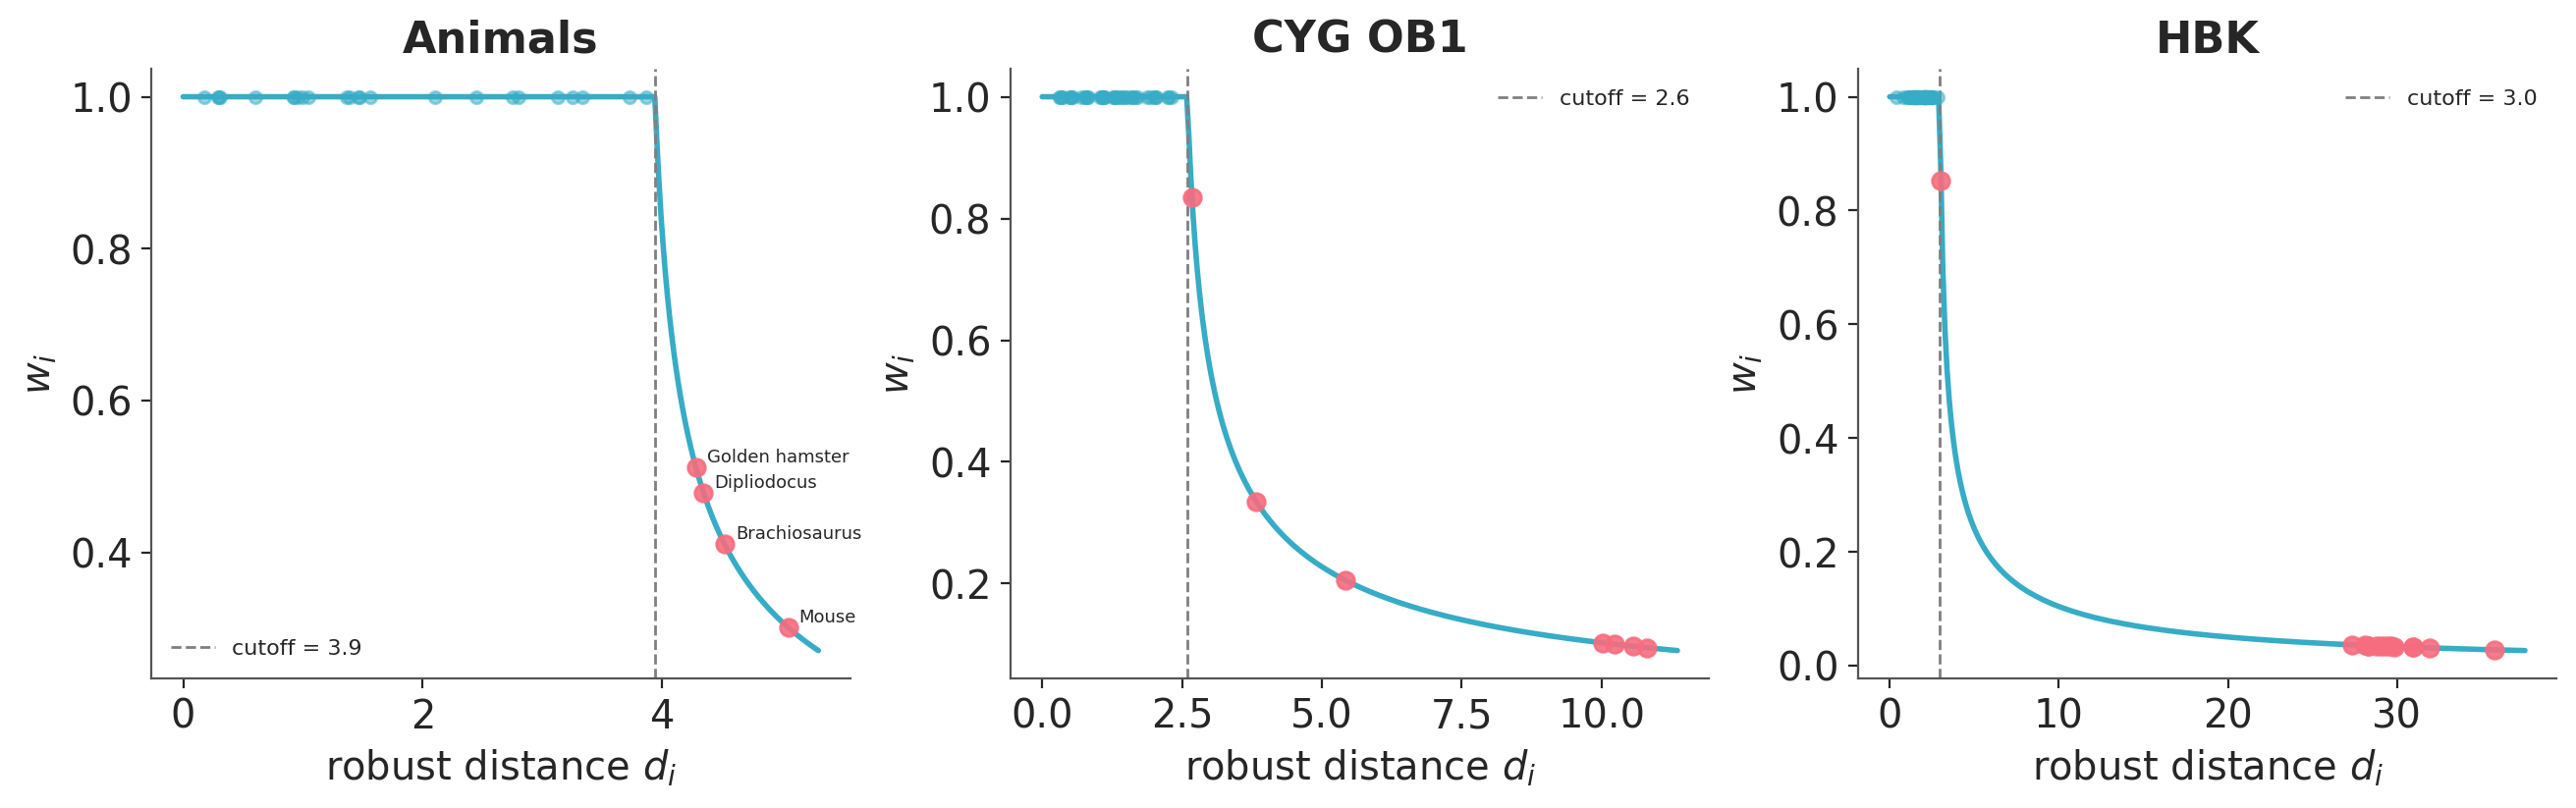

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
datasets = [
    ("Animals", animals_info, animals_weights, animals_df["species"]),
    ("CYG OB1", cyg_info, cyg_weights, None),
    ("HBK", hbk_info, hbk_weights, None),
]
for ax, (title, info, weights, labels) in zip(axes, datasets):
    d, a = info["distances"], info["cutoff"]
    d_plot = np.linspace(0, d.max() * 1.05, 300)
    w_plot = np.where(d_plot <= a, 1.0, 1.0 / np.sqrt(np.maximum(1.0, 1 + d_plot**2 - a**2)))
    ax.plot(d_plot, w_plot, color="C0", lw=2, zorder=2)
    ax.axvline(a, color="gray", ls="--", lw=1, label=f"cutoff = {a:.1f}")
    mask = weights < 1.0
    ax.scatter(d[~mask], weights[~mask], color="C0", alpha=0.5, s=20, zorder=3)
    ax.scatter(d[mask], weights[mask], color="C1", alpha=0.9, s=40, zorder=4)
    if labels is not None:
        for i in np.where(mask)[0]:
            ax.annotate(
                labels.iloc[i],
                (d[i], weights[i]),
                fontsize=6.5,
                xytext=(4, 2),
                textcoords="offset points",
            )
    ax.set_xlabel("robust distance $d_i$")
    ax.set_ylabel("$w_i$")
    ax.set_title(title)
    ax.legend(fontsize=8)

## Sensitivity to the tuning parameter $k$

The cutoff $a = \text{median}(d) + k \cdot \text{MAD}(d)$ is controlled by
$k$. A small $k$ is aggressive (more observations downweighted); a large $k$
is conservative. We vary $k \in \{1, 2, 3, 5\}$ on the Animals dataset and
compare the resulting slope posteriors.

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Multiprocess sampling (4 chains in 4 jobs)


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


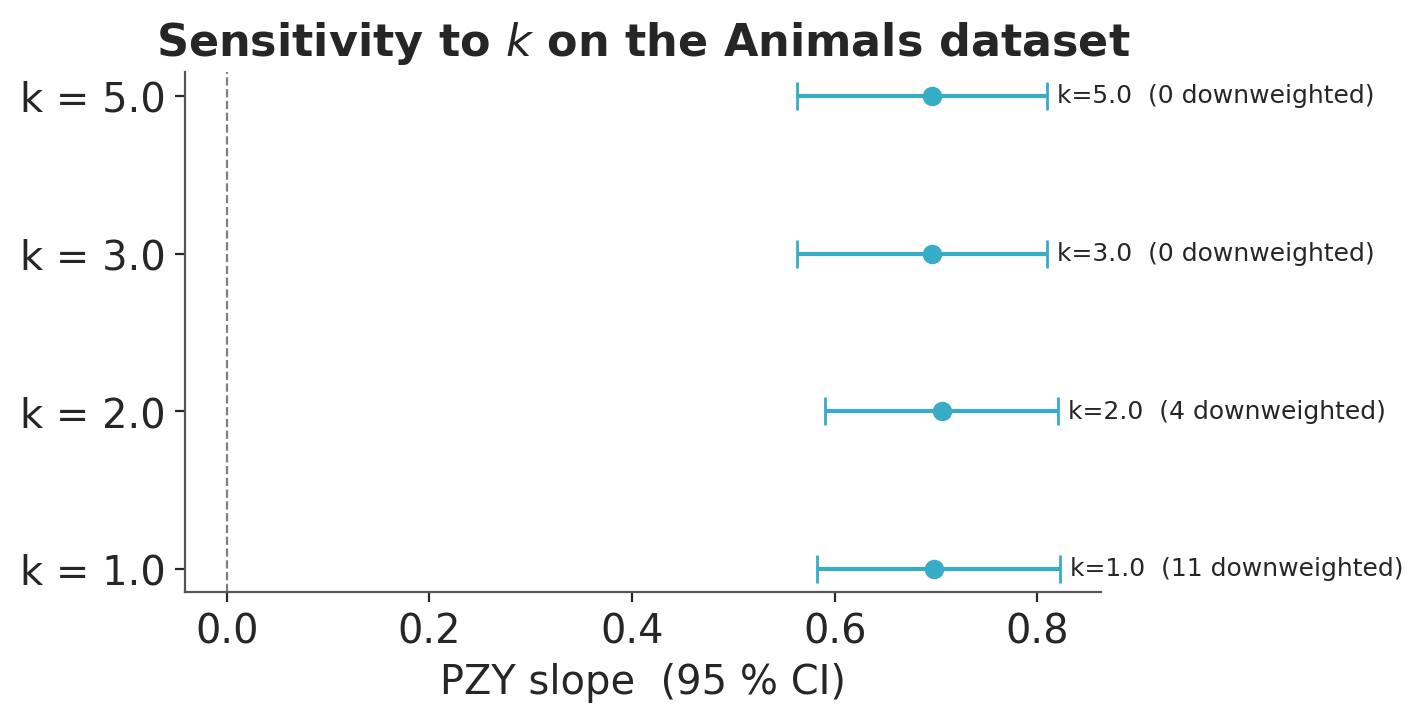

In [14]:
k_values = [1.0, 2.0, 3.0, 5.0]
k_results = {}

for k_val in k_values:
    idata_k, _, weights_k, _ = fit_pzy(
        animals_X,
        animals_y,
        predictor_names=["log_body"],
        k=k_val,
        draws=1000,
        tune=1000,
    )
    mean, lo, hi = _slope_hdi(idata_k, "log_body")
    k_results[k_val] = (mean, lo, hi, int((weights_k < 1).sum()))

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, k_val in enumerate(k_values):
    mean, lo, hi, n_down = k_results[k_val]
    ax.errorbar(mean, i, xerr=[[mean - lo], [hi - mean]], fmt="o", color="C0", capsize=5)
    ax.text(hi + 0.01, i, f"k={k_val}  ({n_down} downweighted)", va="center", fontsize=9)
ax.set_yticks(range(len(k_values)))
ax.set_yticklabels([f"k = {k}" for k in k_values])
ax.set_xlabel("PZY slope  (95 % CI)")
ax.set_title("Sensitivity to $k$ on the Animals dataset")
ax.axvline(0, color="gray", ls="--", lw=0.8)

## Limitations

* **Good leverage points are downweighted too.** The distance-based criterion
  cannot tell a harmful leverage point from a useful one. Extreme but valid
  observations on the true regression surface still get reduced weight, which
  widens credible intervals.

* **Single-cluster assumption.** The quadrant correlation estimates a single
  robust center for the joint distribution of $(y, X)$. If the predictor
  space has more than one cluster, the algorithm may flag a real secondary
  cluster as leverage points.

* **Weights are pre-computed, not sampled.** The $w_i$ are fixed before MCMC
  starts and do not adapt as the posterior of $\beta$ is explored. A fully
  Bayesian treatment would model the weights as random variables, but that
  is much harder to fit.

* **Not appropriate for structured data.** The i.i.d. error assumption that
  justifies the quadrant-correlation distance breaks down for hierarchical
  models, time series, or any other data with dependence between observations.

## Authors

* Authored by Pablo Vena in April 2026

## References

:::{bibliography}
:filter: docname in docnames
:::

In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Tue, 12 May 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.13.0

pytensor: 3.0.1
xarray  : 2026.4.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
pymc      : 5.28.0+87.g9491f60db

Watermark: 2.6.0



:::{include} ../page_footer.md
:::